# Lab 3: Feature Scaling
Task 1: Z-Score Scaling & Task 2: Min-Max Normalization

In [1]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Find CSV file in current folder and load only the first 2,000 rows
csv_file = glob.glob("*.csv")[0]
df = pd.read_csv(csv_file).head(2000)

print(f"Loaded {len(df)} rows from '{csv_file}'")
print(df.head())

Loaded 2000 rows from 'weatherHistory 2.csv'
                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0        

## Feature Selection
We select continuous numerical columns for scaling and exclude text, dates, and constant columns (`Loud Cover` has 0 variance).

In [2]:
# Inspect column data types
print(df.dtypes)

# Selected continuous numerical features
features = [
    'Temperature (C)',
    'Apparent Temperature (C)',
    'Humidity',
    'Wind Speed (km/h)',
    'Wind Bearing (degrees)',
    'Visibility (km)',
    'Pressure (millibars)'
]

print(df[features].head())

Formatted Date               object
Summary                      object
Precip Type                  object
Temperature (C)             float64
Apparent Temperature (C)    float64
Humidity                    float64
Wind Speed (km/h)           float64
Wind Bearing (degrees)      float64
Visibility (km)             float64
Loud Cover                  float64
Pressure (millibars)        float64
Daily Summary                object
dtype: object
   Temperature (C)  Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0         9.472222                  7.388889      0.89            14.1197   
1         9.355556                  7.227778      0.86            14.2646   
2         9.377778                  9.377778      0.89             3.9284   
3         8.288889                  5.944444      0.83            14.1036   
4         8.755556                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Pressure (millibars)  
0                   251.

## Task 1 — Z-Score Scaling
Standardize features to have a mean of 0 and standard deviation of 1.

In [3]:
# Task 1: Z-Score Scaling
scaler_z = StandardScaler()
df_zscore = df.copy()
df_zscore[features] = scaler_z.fit_transform(df[features])

# Verify mean ≈ 0 and std = 1
print("Z-Score Scaled Features (Mean and Std):")
print(df_zscore[features].agg(['mean', 'std']).round(4))

print(df_zscore[features].head())

Z-Score Scaled Features (Mean and Std):
      Temperature (C)  Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
mean           0.0000                   -0.0000   -0.0000             0.0000   
std            1.0003                    1.0003    1.0003             1.0003   

      Wind Bearing (degrees)  Visibility (km)  Pressure (millibars)  
mean                 -0.0000           0.0000                0.0000  
std                   1.0003           1.0003                1.0003  
   Temperature (C)  Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0        -0.302880                 -0.411887  0.571682           0.723091   
1        -0.316550                 -0.428833  0.396490           0.747100   
2        -0.313946                 -0.202696  0.571682          -0.965560   
3        -0.441532                 -0.563814  0.221297           0.720423   
4        -0.386853                 -0.455128  0.221297           0.213561   

   Wind Bearing (degrees)  Visibility (km)  Pr

### Visualization: Before vs After Z-Score Scaling
Comparing original and standardized temperature distributions.

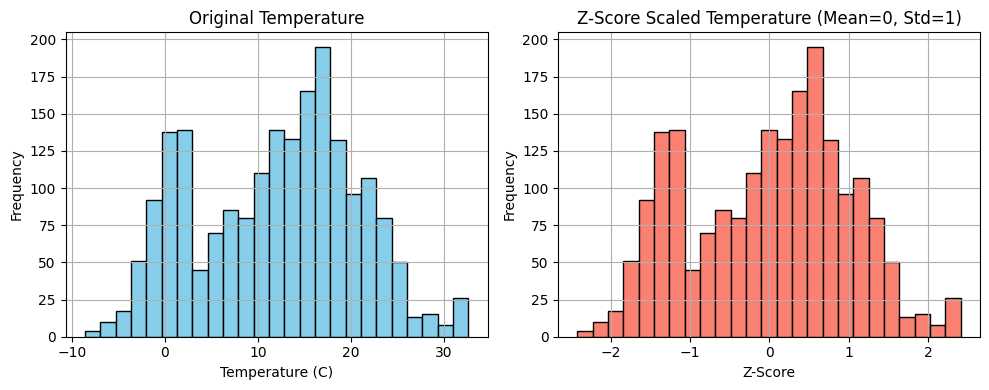

In [4]:
# Visualize Temperature before vs after Z-score scaling
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['Temperature (C)'].hist(bins=25, color='skyblue', edgecolor='black')
plt.title('Original Temperature')
plt.xlabel('Temperature (C)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df_zscore['Temperature (C)'].hist(bins=25, color='salmon', edgecolor='black')
plt.title('Z-Score Scaled Temperature (Mean=0, Std=1)')
plt.xlabel('Z-Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Task 2 — Min-Max Normalization
Rescale features to a fixed range between 0 and 1.

In [5]:
# Task 2: Min-Max Normalization
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[features] = scaler_minmax.fit_transform(df[features])

# Verify min = 0 and max = 1
print("Min-Max Normalized Features (Min and Max):")
print(df_minmax[features].agg(['min', 'max']).round(4))

print(df_minmax[features].head())

Min-Max Normalized Features (Min and Max):
     Temperature (C)  Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
min              0.0                       0.0       0.0                0.0   
max              1.0                       1.0       1.0                1.0   

     Wind Bearing (degrees)  Visibility (km)  Pressure (millibars)  
min                     0.0              0.0                   0.0  
max                     1.0              1.0                   1.0  
   Temperature (C)  Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0         0.438157                  0.407125  0.838235           0.388053   
1         0.435327                  0.403727  0.794118           0.392035   
2         0.435866                  0.449080  0.838235           0.107965   
3         0.409458                  0.376655  0.750000           0.387611   
4         0.420776                  0.398453  0.750000           0.303540   

   Wind Bearing (degrees)  Visibility (km)  Press

### Visualization: Before vs After Min-Max Normalization
Comparing original and normalized temperature distributions.

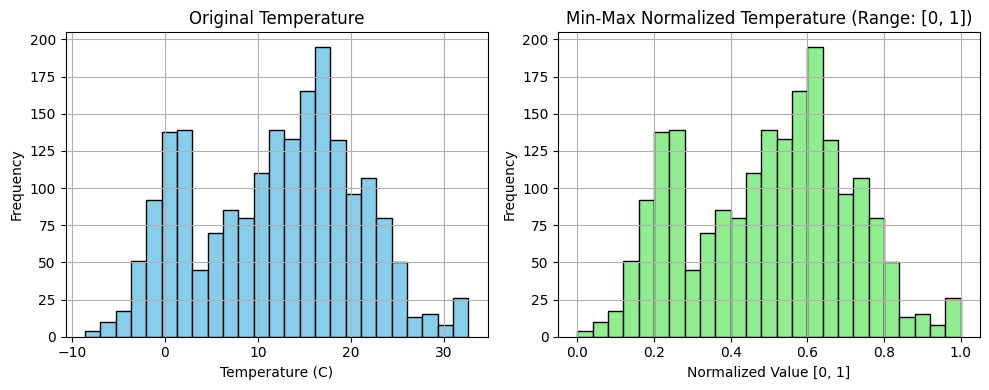

In [6]:
# Visualize Temperature before vs after Min-Max normalization
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['Temperature (C)'].hist(bins=25, color='skyblue', edgecolor='black')
plt.title('Original Temperature')
plt.xlabel('Temperature (C)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df_minmax['Temperature (C)'].hist(bins=25, color='lightgreen', edgecolor='black')
plt.title('Min-Max Normalized Temperature (Range: [0, 1])')
plt.xlabel('Normalized Value [0, 1]')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Visual Comparison of All 3 Scales
Side-by-side boxplots showing how scaling aligns the ranges of all features.

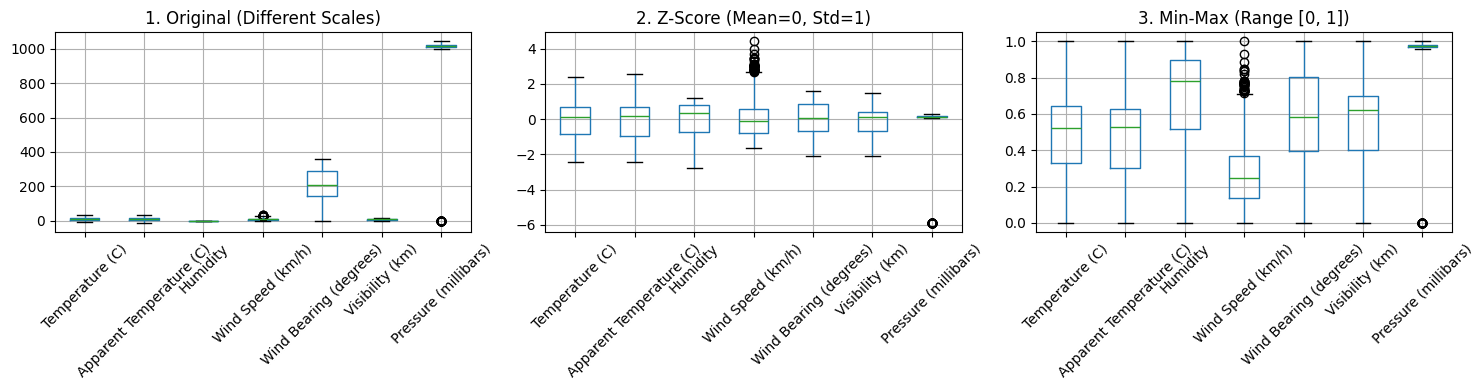

In [7]:
# Boxplot comparison across all 3 representations
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
df[features].boxplot(rot=45)
plt.title('1. Original (Different Scales)')

plt.subplot(1, 3, 2)
df_zscore[features].boxplot(rot=45)
plt.title('2. Z-Score (Mean=0, Std=1)')

plt.subplot(1, 3, 3)
df_minmax[features].boxplot(rot=45)
plt.title('3. Min-Max (Range [0, 1])')

plt.tight_layout()
plt.show()